###**2nd Challenge AN2DL [2025-2026]: Image Classification 2.0** 🔬


## **Libraries import**

In [ ]:
import os
import warnings
import logging
import random
import shutil
import copy
import zipfile
import time
from io import BytesIO
from itertools import product
from concurrent.futures import ThreadPoolExecutor

# Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
import requests

# Reproducibility
np.random.seed(SEED)
random.seed(SEED)

# Plot configuration
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from tqdm import tqdm
from tqdm.notebook import tqdm


import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    Dataset
)
from torch.utils.tensorboard import SummaryWriter

# Torch reproducibility
torch.manual_seed(SEED)

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


import torchvision
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms
from torchvision import transforms

!pip install torchview
from torchview import draw_graph

import albumentations as A
from albumentations.pytorch import ToTensorV2


logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight


from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

PyTorch version: 2.9.0+cu126
Device: cuda


## **Google Drive + Kaggle Connection**

In [ ]:
from google.colab import drive
if not os.path.exists('/content/drive'):
    print("Connecting to Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive already connected.")

Connecting to Google Drive...
Mounted at /content/drive


In [ ]:
#installing kaggle
!pip install --upgrade --force-reinstall --no-deps kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


## **Data Loading**

In [ ]:
COMPETITION_NAME = "an2dl2526c2v2"
DATASET_FOLDER = "dataset" #Folder where the data will be
KAGGLE_JSON_PATH_DRIVE = "/content/drive/MyDrive/2nd Challenge/kaggle.json"

In [ ]:
#Check if data already downloaded
if(False):
    print(f"\n Data have been already downloaded in '{DATASET_FOLDER}'. Skip download.")

else:
    print("Let's start download...")
    # SETUP KAGGLE
    if os.path.exists(KAGGLE_JSON_PATH_DRIVE):
        print(f"Access to kaggle using these credentials: {KAGGLE_JSON_PATH_DRIVE}")

        !mkdir -p ~/.kaggle
        !cp "{KAGGLE_JSON_PATH_DRIVE}" ~/.kaggle/kaggle.json
        !chmod 600 ~/.kaggle/kaggle.json

        print("Granted access")

        # Test connection
        print("testing connection...")
        try:
            !kaggle competitions list | head -n 3
            print("Connection OK!")
        except:
            print("Impossible listing competitions, trying download.")

        # DOWNLOAD AND UNZIP
        print(f"\n Downloading challenge {COMPETITION_NAME}...")
        try:
            !kaggle competitions download -c {COMPETITION_NAME}

            zip_file = f"{COMPETITION_NAME}.zip"
            if os.path.exists(zip_file):
                print(f" Extracting in '{DATASET_FOLDER}'...")
                !mkdir -p {DATASET_FOLDER}
                !unzip -q {zip_file} -d {DATASET_FOLDER}
                os.remove(zip_file)
                print(f" Data ready in: {DATASET_FOLDER}")
            else:
                print("Error: Download failed (zip not found).")

        except Exception as e:
            print(f"❌ Error during download: {e}")

    else:
        print(f"error: file kaggle.json not at {KAGGLE_JSON_PATH_DRIVE}")

Let's start download...
Access to kaggle using these credentials: /content/drive/MyDrive/2nd Challenge/kaggle.json
Granted access
testing connection...
ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd        795           False  
Connection OK!

 99% 927M/936M [00:09<00:00, 35.7MB/s]
100% 936M/936M [00:09<00:00, 107MB/s] 
 Extracting in 'dataset'...
 Data ready in: dataset


Images/Masks reordering into correct folders

In [ ]:
BASE_DIR = 'dataset'

#source folders
SOURCE_TRAIN_DIR = os.path.join(BASE_DIR, 'train_data')
SOURCE_TEST_DIR = os.path.join(BASE_DIR, 'test_data')

#destination folders
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_images')
TRAIN_MASK_DIR = os.path.join(BASE_DIR, 'train_masks')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_images')
TEST_MASK_DIR = os.path.join(BASE_DIR, 'test_masks')

#creating destination folders if not existing
for d in [TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print("Starting data organization in folders...")

# management train data
if os.path.exists(SOURCE_TRAIN_DIR):
    print(f" found source folder: {SOURCE_TRAIN_DIR}")

    # collect images
    files = [f for f in os.listdir(SOURCE_TRAIN_DIR) if os.path.isfile(os.path.join(SOURCE_TRAIN_DIR, f))]

    if len(files) == 0:
        print("train_data folder is empty! Maybe images were already been moved?")
    else:
        print(f"Moving {len(files)} files...")

        for file in tqdm(files, desc="Train movement"):
            src_path = os.path.join(SOURCE_TRAIN_DIR, file)

            # Movement logic: we want to separate mask and images
            if file.startswith('img_'):
                shutil.move(src_path, os.path.join(TRAIN_IMG_DIR, file))
            elif file.startswith('mask_'):
                shutil.move(src_path, os.path.join(TRAIN_MASK_DIR, file))

        print("Training Data organized.")
else:
    print(f"Error: folder {SOURCE_TRAIN_DIR} not found")

# managing test data
if os.path.exists(SOURCE_TEST_DIR):
    print(f"found source folder:{SOURCE_TEST_DIR}")

    files = [f for f in os.listdir(SOURCE_TEST_DIR) if os.path.isfile(os.path.join(SOURCE_TEST_DIR, f))]

    if len(files) == 0:
        print("test_data folder is empty! Maybe images were already been moved?")
    else:
        print(f"Moving {len(files)} files...")

        for file in tqdm(files, desc="Test movement"):
            src_path = os.path.join(SOURCE_TEST_DIR, file)

            if file.startswith('img_'):
                shutil.move(src_path, os.path.join(TEST_IMG_DIR, file))
            elif file.startswith('mask_'):
                shutil.move(src_path, os.path.join(TEST_MASK_DIR, file))

        print("Test Data organized.")
else:
    print(f"Error: folder {SOURCE_TRAIN_DIR} not found")

# verifying if also labels are in right place
path_labels = os.path.join(BASE_DIR, 'train_labels.csv')
if os.path.exists(path_labels):
    print(f"labels file found: {path_labels}")
else:
    print("labels file not found in dataset root.")


Starting data organization in folders...
 found source folder: dataset/train_data
Moving 1382 files...


Train movement:   0%|          | 0/1382 [00:00<?, ?it/s]

Training Data organized.
found source folder:dataset/test_data
Moving 954 files...


Test movement:   0%|          | 0/954 [00:00<?, ?it/s]

Test Data organized.
labels file found: dataset/train_labels.csv


## **Outliers & Duplicates Removal**

Here we exploit the text files we created did in the other notebook to remove all outliers and duplicates. Basically we analyzed all the train images and we inserted all the wrong images' names inside the respective text files. Here we use these to actually removethe wrong images (and their respective masks) from our folders.

In [ ]:
drive_mapping_paths = {
    'new_dataset_final_list_shrek_images.txt' : '/content/drive/MyDrive/2nd Challenge/new_dataset_final_list_shrek_images.txt',
    'new_dataset_mask_shrek_images.txt' : '/content/drive/MyDrive/2nd Challenge/new_dataset_mask_shrek_images.txt',
    'new_dataset_final_sorted_skifidol_paths.txt' : '/content/drive/MyDrive/2nd Challenge/new_dataset_final_sorted_skifidol_paths.txt',
    'new_dataset_masks_skifidol_paths.txt' : '/content/drive/MyDrive/2nd Challenge/new_dataset_masks_skifidol_paths.txt'
}

In [ ]:
# txt files list for images
file_list = [
    'new_dataset_final_list_shrek_images.txt',
    'new_dataset_mask_shrek_images.txt'
]

for file_name in file_list:
    print(f"Cleaning list: {file_name}")

    if not os.path.exists(drive_mapping_paths.get(file_name)):
        print(f"Error: file {file_name} was not found.")
        continue

    with open(drive_mapping_paths.get(file_name), 'r') as f:
        paths_to_delete = [line.strip() for line in f.readlines() if line.strip()]

    count_deleted = 0

    for path in paths_to_delete:
        if os.path.exists(path):
            try:
                os.remove(path)
                print(f"Deleted: {path}")
                count_deleted += 1
            except Exception as e:
                print(f"Error deleting {path}: {e}")
        else:
            # Optional
            print(f"Skipped (not found): {path}")
            pass

    print(f"\n--- Total deleted {file_name}: {count_deleted} ---\n")


Cleaning list: new_dataset_final_list_shrek_images.txt
Deleted: dataset/train_images/img_0005.png
Deleted: dataset/train_images/img_0008.png
Deleted: dataset/train_images/img_0022.png
Deleted: dataset/train_images/img_0027.png
Deleted: dataset/train_images/img_0036.png
Deleted: dataset/train_images/img_0048.png
Deleted: dataset/train_images/img_0062.png
Deleted: dataset/train_images/img_0085.png
Deleted: dataset/train_images/img_0095.png
Deleted: dataset/train_images/img_0126.png
Deleted: dataset/train_images/img_0129.png
Deleted: dataset/train_images/img_0133.png
Deleted: dataset/train_images/img_0136.png
Deleted: dataset/train_images/img_0138.png
Deleted: dataset/train_images/img_0148.png
Deleted: dataset/train_images/img_0155.png
Deleted: dataset/train_images/img_0159.png
Deleted: dataset/train_images/img_0178.png
Deleted: dataset/train_images/img_0179.png
Deleted: dataset/train_images/img_0180.png
Deleted: dataset/train_images/img_0187.png
Deleted: dataset/train_images/img_0189.png

##### Given the communication that images containing green blobs were basically duplicates of correct images already present inside our dataset we can skip the logic we were previously using to clean these images (and their masks) to adapt them with other train images. We leave this old logic commented here anyway for completeness.

Code for cleaning images containing a 'Green Blob' and their respective masks.

In [ ]:
'''
# Set this number to how many examples you want to see plotted at the end
NUM_TO_VISUALIZE = 100  # (all of them)

file_lista_skifidol = 'new_dataset_final_sorted_skifidol_paths.txt'
input_img_dir = TRAIN_IMG_DIR   # Ensure these path variables are defined
input_mask_dir = TRAIN_MASK_DIR

# --- HSV SETTINGS ---
lower_green = np.array([35, 25, 25])
upper_green = np.array([90, 255, 255])

# List to store samples for visualization
visualization_samples = []

# Load paths
paths_to_process = []
if os.path.exists(file_lista_skifidol):
    with open(file_lista_skifidol, 'r') as f:
        paths_to_process = [line.strip() for line in f.readlines() if line.strip()]
    print(f"Found {len(paths_to_process)} files to process.")
else:
    # Fallback to dictionary method if file not found directly
    try:
        if os.path.exists(drive_mapping_paths.get(file_lista_skifidol)):
            with open(drive_mapping_paths.get(file_lista_skifidol), 'r') as f:
                paths_to_process = [line.strip() for line in f.readlines() if line.strip()]
            print(f"Found {len(paths_to_process)} files to process.")
    except:
        print(f"ERROR: Could not find {file_lista_skifidol}")
        paths_to_process = []

count = 0

for file_entry in paths_to_process:
    filename = os.path.basename(file_entry)

    # Resolve naming convention
    if "mask" in filename:
        mask_name = filename
        img_name = filename.replace("mask", "img")
    else:
        img_name = filename
        mask_name = filename.replace("img", "mask")

    full_img_path = os.path.join(input_img_dir, img_name)
    full_mask_path = os.path.join(input_mask_dir, mask_name)

    if not os.path.exists(full_img_path) or not os.path.exists(full_mask_path):
        continue

    # Load Images
    img_orig = cv2.imread(full_img_path)
    mask_orig = cv2.imread(full_mask_path, 0)

    if img_orig is None or mask_orig is None:
        continue

    # --- 1. Detect Blob ---
    hsv = cv2.cvtColor(img_orig, cv2.COLOR_BGR2HSV)
    green_blob_mask = cv2.inRange(hsv, lower_green, upper_green)

    # --- 2. Dilate Mask ---
    # Expand slightly to catch green edges/fringes
    kernel = np.ones((12, 12), np.uint8)
    green_blob_mask = cv2.dilate(green_blob_mask, kernel, iterations=3)

    # --- 3. Clean Image (Inpainting) ---
    # Fills the blob area using surrounding pixels
    img_cleaned = cv2.inpaint(img_orig, green_blob_mask, 3, cv2.INPAINT_TELEA)

    # --- 4. Clean Mask ---
    # Forces the mask to 0 (black) where the blob was
    mask_cleaned = cv2.bitwise_and(mask_orig, mask_orig, mask=~green_blob_mask)

    # --- SAVE UPDATED FILES (Overwrite) ---
    cv2.imwrite(full_img_path, img_cleaned)
    cv2.imwrite(full_mask_path, mask_cleaned)

    # --- STORE FOR VISUALIZATION ---
    # Only store the first N images to avoid memory issues
    if len(visualization_samples) < NUM_TO_VISUALIZE:
        visualization_samples.append({
            'orig_w_blob': img_orig,
            'cleaned_img': img_cleaned,
            'final_mask': mask_cleaned
        })

    count += 1
    if count % 20 == 0:
        print(f"Processed {count} images...")

print(f"Done! {count} images cleaned and overwritten.")

# --- INLINE PLOTTING ---
if len(visualization_samples) > 0:
    print(f"Visualizing {len(visualization_samples)} samples...")
    # Dynamic height: 5 inches per row
    plt.figure(figsize=(15, 5 * len(visualization_samples)))

    for i, sample in enumerate(visualization_samples):
        # Convert BGR to RGB for matplotlib
        orig_rgb = cv2.cvtColor(sample['orig_w_blob'], cv2.COLOR_BGR2RGB)
        clean_rgb = cv2.cvtColor(sample['cleaned_img'], cv2.COLOR_BGR2RGB)

        # 1. Normal Image (with Blob)
        plt.subplot(len(visualization_samples), 3, i*3 + 1)
        plt.imshow(orig_rgb)
        plt.title(f"Sample {i+1}: Original (With Blob)")
        plt.axis('off')

        # 2. Cleaned Image
        plt.subplot(len(visualization_samples), 3, i*3 + 2)
        plt.imshow(clean_rgb)
        plt.title(f"Sample {i+1}: Cleaned Image")
        plt.axis('off')

        # 3. Final Mask
        plt.subplot(len(visualization_samples), 3, i*3 + 3)
        plt.imshow(sample['final_mask'], cmap='gray')
        plt.title(f"Sample {i+1}: Final Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No samples found to visualize.")'''

'\n# Set this number to how many examples you want to see plotted at the end\nNUM_TO_VISUALIZE = 100  # (all of them)\n\nfile_lista_skifidol = \'new_dataset_final_sorted_skifidol_paths.txt\'\ninput_img_dir = TRAIN_IMG_DIR   # Ensure these path variables are defined\ninput_mask_dir = TRAIN_MASK_DIR\n\n# --- HSV SETTINGS ---\nlower_green = np.array([35, 25, 25])\nupper_green = np.array([90, 255, 255])\n\n# List to store samples for visualization\nvisualization_samples = []\n\n# Load paths\npaths_to_process = []\nif os.path.exists(file_lista_skifidol):\n    with open(file_lista_skifidol, \'r\') as f:\n        paths_to_process = [line.strip() for line in f.readlines() if line.strip()]\n    print(f"Found {len(paths_to_process)} files to process.")\nelse:\n    # Fallback to dictionary method if file not found directly\n    try:\n        if os.path.exists(drive_mapping_paths.get(file_lista_skifidol)):\n            with open(drive_mapping_paths.get(file_lista_skifidol), \'r\') as f:\n         

#####Actual deletion of 'Green Blob' images

In [ ]:
# Text files list
file_list = [
    'new_dataset_final_sorted_skifidol_paths.txt',
    'new_dataset_masks_skifidol_paths.txt'
]

for file_name in file_list:
    print(f"Cleaning list: {file_name}")

    if not os.path.exists(drive_mapping_paths.get(file_name)):
        print(f"Error: file {file_name} was not found.")
        continue

    with open(drive_mapping_paths.get(file_name), 'r') as f:
        paths_to_delete = [line.strip() for line in f.readlines() if line.strip()]

    count_deleted = 0

    for path in paths_to_delete:
        if os.path.exists(path):
            try:
                os.remove(path)
                print(f"Deleted: {path}")
                count_deleted += 1
            except Exception as e:
                print(f"Error deleting {path}: {e}")
        else:
            # Optional
            print(f"Skipped (not found): {path}")
            pass

    print(f"\n--- Total deleted {file_name}: {count_deleted} ---\n")

Cleaning list: new_dataset_final_sorted_skifidol_paths.txt
Deleted: dataset/train_images/img_0001.png
Deleted: dataset/train_images/img_0012.png
Deleted: dataset/train_images/img_0018.png
Deleted: dataset/train_images/img_0020.png
Deleted: dataset/train_images/img_0028.png
Deleted: dataset/train_images/img_0044.png
Deleted: dataset/train_images/img_0047.png
Deleted: dataset/train_images/img_0052.png
Deleted: dataset/train_images/img_0078.png
Deleted: dataset/train_images/img_0090.png
Deleted: dataset/train_images/img_0094.png
Deleted: dataset/train_images/img_0130.png
Deleted: dataset/train_images/img_0150.png
Deleted: dataset/train_images/img_0161.png
Deleted: dataset/train_images/img_0175.png
Deleted: dataset/train_images/img_0184.png
Deleted: dataset/train_images/img_0222.png
Deleted: dataset/train_images/img_0268.png
Deleted: dataset/train_images/img_0293.png
Deleted: dataset/train_images/img_0333.png
Deleted: dataset/train_images/img_0342.png
Deleted: dataset/train_images/img_0355

## **Class distributions**

Let's see how training images are distributed w.r.t. to the different classes now that our dataset is clean.

In [ ]:
df_labels = pd.read_csv(os.path.join(BASE_DIR, 'train_labels.csv'))
df_labels.head()

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B


In [ ]:
# We add the path of each image for later use
df_labels['path'] = 'dataset/train_images/' + df_labels['sample_index']
df_labels.head()

,sample_index,label,path
0,img_0000.png,Triple negative,dataset/train_images/img_0000.png
1,img_0001.png,Luminal B,dataset/train_images/img_0001.png
2,img_0002.png,Luminal B,dataset/train_images/img_0002.png
3,img_0003.png,Luminal B,dataset/train_images/img_0003.png
4,img_0004.png,Luminal B,dataset/train_images/img_0004.png


In [ ]:
# We remove all the wrong images also from the train labels dataframe
file_to_remove_paths = '/content/drive/MyDrive/2nd Challenge/new_dataset_final_list_shrek_images.txt'

# Read paths from the file
with open(file_to_remove_paths, 'r') as f:
    paths_to_remove = {line.strip() for line in f if line.strip()}

# Filter the DataFrame: keep rows where 'path' is NOT in paths_to_remove
df_labels = df_labels[~df_labels['path'].isin(paths_to_remove)]

print(f"Removed {len(paths_to_remove)} entries from the training dataframe.")
df_labels.head(10)

Removed 60 entries from the training dataframe.


,sample_index,label,path
0,img_0000.png,Triple negative,dataset/train_images/img_0000.png
1,img_0001.png,Luminal B,dataset/train_images/img_0001.png
2,img_0002.png,Luminal B,dataset/train_images/img_0002.png
3,img_0003.png,Luminal B,dataset/train_images/img_0003.png
4,img_0004.png,Luminal B,dataset/train_images/img_0004.png
6,img_0006.png,Luminal A,dataset/train_images/img_0006.png
7,img_0007.png,Luminal B,dataset/train_images/img_0007.png
9,img_0009.png,Luminal B,dataset/train_images/img_0009.png
10,img_0010.png,Luminal B,dataset/train_images/img_0010.png
11,img_0011.png,Luminal A,dataset/train_images/img_0011.png


In [ ]:
# initially we had 691 images
len(df_labels)

631

In [ ]:
file_to_remove_paths = '/content/drive/MyDrive/2nd Challenge/new_dataset_final_sorted_skifidol_paths.txt'

# Read paths from the file
with open(file_to_remove_paths, 'r') as f:
    paths_to_remove = {line.strip() for line in f if line.strip()}

# Filter the DataFrame: keep rows where 'path' is NOT in paths_to_remove
df_labels = df_labels[~df_labels['path'].isin(paths_to_remove)]

print(f"Removed {len(paths_to_remove)} entries from the training dataframe.")
df_labels.head(10)

Removed 50 entries from the training dataframe.


,sample_index,label,path
0,img_0000.png,Triple negative,dataset/train_images/img_0000.png
2,img_0002.png,Luminal B,dataset/train_images/img_0002.png
3,img_0003.png,Luminal B,dataset/train_images/img_0003.png
4,img_0004.png,Luminal B,dataset/train_images/img_0004.png
6,img_0006.png,Luminal A,dataset/train_images/img_0006.png
7,img_0007.png,Luminal B,dataset/train_images/img_0007.png
9,img_0009.png,Luminal B,dataset/train_images/img_0009.png
10,img_0010.png,Luminal B,dataset/train_images/img_0010.png
11,img_0011.png,Luminal A,dataset/train_images/img_0011.png
13,img_0013.png,HER2(+),dataset/train_images/img_0013.png


In [ ]:
len(df_labels)

581

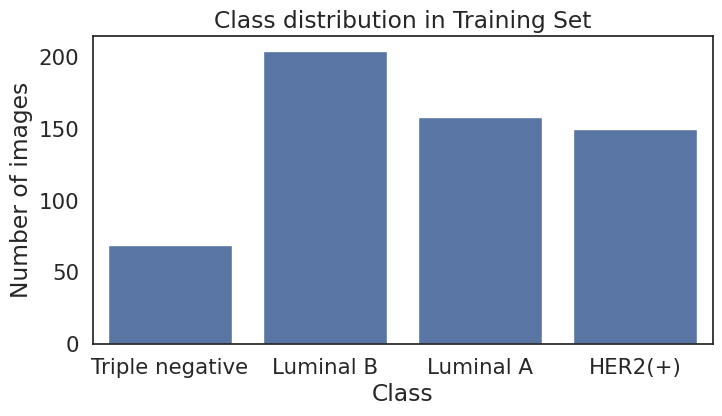


Number of images in each class:
Class Triple negative: 69 images
Class Luminal B: 204 images
Class Luminal A: 158 images
Class HER2(+): 150 images


In [ ]:
#let's visualize class distribution
df_labels['sample_index'] = df_labels['sample_index'].astype(str)

plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df_labels)
plt.title("Class distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

print('\nNumber of images in each class:')

for label in df_labels['label'].unique():
    label_count = df_labels[df_labels['label'] == label].shape[0]
    print(f"Class {label}: {label_count} images")

Still unbalanced after the cleaning, with most images from class Luminal B and a low number of images from class Triple negative.

## **Data Preprocessing + Healthy Tissue Strategy**
Our data pipeline consists of two distinct stages: one **Offline Preprocessing** (patching) step and a separate **Online Data Augmentation** done during training. In doing this we also implemented a strategy defined here in the next cell.

**Healthy Tissue Strategy:**

In the creation of these patches we find discrepancy between global labels (assigned to the entire slide) and local features (present in specific patches). A slide labeled as 'Tumor' often contains large regions of healthy tissue. Treating all patches extracted from such a slide as 'Tumor' would introduce significant label noise, forcing the model to erroneously associate healthy tissue features with a pathological label.

To mitigate this, we implemented a mask-guided label refinement strategy:


*   *Tumor Patches:* A patch is assigned a tumor subclass label (e.g., Luminal B) only if the corresponding segmentation mask indicates the presence of tumor pixels above a specific threshold.
*   *Creation of the 'Healthy' Class:* Patches extracted from a tumor slide that contain biological tissue (based on pixel intensity analysis) but correspond to an empty region in the segmentation mask are re-labeled as 'Healthy'.


This approach effectively transforms the problem from a simple tumor classification into a more robust discrimination task. By explicitly training the model on a 'Healthy' class, we force the network to learn the specific  boundaries between normal and cancerous cells, rather than simply distinguishing tissue from background. This approach reduces false positives and improves the model's ability to generalize on unseen data.

###**Offline Preprocessing - Patch Generation**

We verify the dataset integrity and decompose high-resolution images into manageable tiles (224x224) to match the CNN input size. This step also involves the dynamic creation of the 'Healthy' class.

We create a dataframe that contains paths of images and masks as well their labels.

In [ ]:
#create the data frame with all the information needed
train_df = pd.DataFrame({
    'img_idx': df_labels['sample_index'],
    'path_img': df_labels['path'],
    'path_mask':df_labels['path'].str.replace('train_images', 'train_masks').str.replace('img_', 'mask_'),
    'label': df_labels['label']
})
train_df.head()

,img_idx,path_img,path_mask,label
0,img_0000.png,dataset/train_images/img_0000.png,dataset/train_masks/mask_0000.png,Triple negative
2,img_0002.png,dataset/train_images/img_0002.png,dataset/train_masks/mask_0002.png,Luminal B
3,img_0003.png,dataset/train_images/img_0003.png,dataset/train_masks/mask_0003.png,Luminal B
4,img_0004.png,dataset/train_images/img_0004.png,dataset/train_masks/mask_0004.png,Luminal B
6,img_0006.png,dataset/train_images/img_0006.png,dataset/train_masks/mask_0006.png,Luminal A


In [ ]:
#checking we have all the masks we generated in the previous cell
def check_existence(path):
    return os.path.exists(path)

missing_masks = train_df[~train_df['path_mask'].apply(check_existence)]

if len(missing_masks) > 0:
    print(f"Warning! Missing {len(missing_masks)} masks.")
    print(missing_masks[['img_idx', 'path_mask']])
else:
    print("All masks exist and the paths are correct")

All masks exist and the paths are correct


Patch creation

In [ ]:
PATCH_SIZE = 224
SAVE_DIR_IMG = 'dataset/patches/images'
SAVE_DIR_MASK = 'dataset/patches/masks'

TUMOR_THRESHOLD = 0.05   # At least 5% tumor to be classified as 'Tumor'
TISSUE_THRESHOLD = 0.10  # At least 10% tissue to not be considered 'Empty'

def reset_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

print("Cleaning output folders...")
reset_folder(SAVE_DIR_IMG)
reset_folder(SAVE_DIR_MASK)


# Stride configuration: we use stricter ones for less frequent classes to try to better balance the classes
class_strides = {
    'Triple negative': 112, # Very aggressive (overlap 50%)
    'HER2(+)': 160,
    'Luminal A': 180,
    'Luminal B': 224        # No overlap (big class)
}

# Filter functions
def has_tumor(patch_mask, threshold=0.05):
    """Checks if there is enought 'Tumor'"""
    tumor_pixels = np.count_nonzero(patch_mask)
    total_pixels = patch_mask.shape[0] * patch_mask.shape[1]
    return (tumor_pixels / total_pixels) > threshold

def is_tissue(patch_img, threshold=0.10):
    """
    Checks if there is tissue in the RBG image (avoids the white background)
    """

    # Convert in HSV (Hue, Saturation, Value) to better separate color and intensity
    hsv = cv2.cvtColor(patch_img, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]
    gray = cv2.cvtColor(patch_img, cv2.COLOR_BGR2GRAY)

    # Mask: (saturated > 15) AND (Not so bright < 235)
    tissue_mask = (saturation > 15) & (gray < 235)

    tissue_pixels = np.count_nonzero(tissue_mask)
    total_pixels = patch_img.shape[0] * patch_img.shape[1]

    return (tissue_pixels / total_pixels) > threshold

# Patching Cycle (5th class generation)
patch_data = []

print(f"Start patching (5 classes) on {len(train_df)} images...")

for index, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = row['path_img']
    mask_path = row['path_mask']
    original_label = row['label'] # Ex: 'Triple negative'
    img_base_name = str(row['img_idx']).replace('.png', '')

    # Loading
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None: continue

    h, w, _ = img.shape

    # Select the stride according to the class of the original tumor
    stride = class_strides.get(original_label, 224)

    # Sliding Window
    for y in range(0, h - PATCH_SIZE + 1, stride):
        for x in range(0, w - PATCH_SIZE + 1, stride):

            patch_mask = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            patch_img = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            final_label = None

            # CASE A: IS it a tumor? (Checking the mask)
            if has_tumor(patch_mask, threshold=TUMOR_THRESHOLD):
                final_label = original_label # Keeps the class (ex. Triple negative)

            # CASE B: It's not tumor, is it healthy tissue? (Checking the image)
            elif is_tissue(patch_img, threshold=TISSUE_THRESHOLD):
                final_label = 'Healthy' # NEW CLASS 5

            # CASE C: Is the background white? --> Discard it
            else:
                continue

            # If we assigned a label save it
            if final_label:
                clean_lbl = final_label.replace(' ', '_').replace('(+)', 'pos')
                fname = f"{img_base_name}_{clean_lbl}_y{y}_x{x}.png"

                save_path_img = os.path.join(SAVE_DIR_IMG, fname)
                save_path_mask = os.path.join(SAVE_DIR_MASK, fname)

                cv2.imwrite(save_path_img, patch_img)
                cv2.imwrite(save_path_mask, patch_mask)

                patch_data.append({
                    'patch_name': fname,
                    'original_img': img_base_name,
                    'label': final_label, # Here we will also have 'Healthy'
                    'path_img': save_path_img,
                    'path_mask': save_path_mask
                })

# Saving and analysis
df_patches = pd.DataFrame(patch_data)
print("\nPatching completed.")
print(f"Total Patches generated: {len(df_patches)}")
print("\nClass distribution (with new 'Healthy' class):")
print(df_patches['label'].value_counts())

# Saving
df_patches.to_csv('dataset_patches_5classes.csv', index=False)

Cleaning output folders...
Start patching (5 classes) on 581 images...


  0%|          | 0/581 [00:00<?, ?it/s]


Patching completed.
Total Patches generated: 10119

Class distribution (with new 'Healthy' class):
label
Healthy            7461
HER2(+)             738
Triple negative     697
Luminal A           638
Luminal B           585
Name: count, dtype: int64


In [ ]:
df_patches.head(20)

,patch_name,original_img,label,path_img,path_mask
0,img_0000_Healthy_y112_x224.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x2...
1,img_0000_Healthy_y112_x336.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x3...
2,img_0000_Healthy_y112_x896.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x8...
3,img_0000_Healthy_y112_x1008.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x1...
4,img_0000_Healthy_y224_x224.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x2...
5,img_0000_Healthy_y224_x336.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x3...
6,img_0000_Healthy_y224_x784.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x7...
7,img_0000_Healthy_y224_x896.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x8...
8,img_0000_Healthy_y224_x1008.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x1...
9,img_0000_Healthy_y336_x112.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y336_x...,dataset/patches/masks/img_0000_Healthy_y336_x1...


In [ ]:
print(df_patches['path_img'][0])

dataset/patches/images/img_0000_Healthy_y112_x224.png


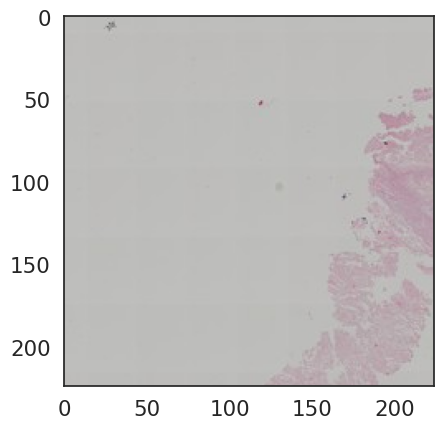

In [ ]:
# Show what has been generated
path = df_patches['path_img'][0]
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

Creating final dataframes of patches

In [ ]:
# Get a unique list of the originl images
# We are not splitting patches, but the original images
unique_images = df_patches['original_img'].unique()

# Divide the images ID: 80% Train, 20% Validation
train_ids, val_ids = train_test_split(unique_images, test_size=0.20, random_state=42)

# Create two final dataframes filtering according to the previous images ID
train_df = df_patches[df_patches['original_img'].isin(train_ids)].reset_index(drop=True)
val_df = df_patches[df_patches['original_img'].isin(val_ids)].reset_index(drop=True)

# Checking images
print(f"Total Original Images:  {len(unique_images)}")
print(f"Images in Training:     {len(train_ids)}")
print(f"Images in Validation:   {len(val_ids)}")
print("-" * 30)
print(f"Total patches in Training:   {len(train_df)}")
print(f"Total patches in Validation: {len(val_df)}")

# Security control: checking there is not the same image both in train and val
assert len(set(train_df['original_img']) & set(val_df['original_img'])) == 0
print("-" * 30)
print("Split completed correctly")

Total Original Images:  581
Images in Training:     464
Images in Validation:   117
------------------------------
Total patches in Training:   7988
Total patches in Validation: 2131
------------------------------
Split completed correctly


In [ ]:
train_df.head()

,patch_name,original_img,label,path_img,path_mask
0,img_0000_Healthy_y112_x224.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x2...
1,img_0000_Healthy_y112_x336.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x3...
2,img_0000_Healthy_y112_x896.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x8...
3,img_0000_Healthy_y112_x1008.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y112_x...,dataset/patches/masks/img_0000_Healthy_y112_x1...
4,img_0000_Healthy_y224_x224.png,img_0000,Healthy,dataset/patches/images/img_0000_Healthy_y224_x...,dataset/patches/masks/img_0000_Healthy_y224_x2...


In [ ]:
# Define the input shape based on the training data
input_shape = (3, 224, 224)

# Define the number of classes
num_classes = 5

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)

Input Shape: (3, 224, 224)
Number of Classes: 5


In [ ]:
# Define the batch size
BATCH_SIZE = 32

####**Class weights computation with the new class 'Healthy'**

In [ ]:
# Device Configuration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


# Map definition for the new class
class_map = {
    'Triple negative': 0,
    'Luminal A': 1,
    'Luminal B': 2,
    'HER2(+)': 3,
    'Healthy': 4  # NEW CLASS
}

print("Computing the weights for these classes:", list(class_map.keys()))

# Label mapping to numbers using class_map
y_train_indices = df_patches['label'].map(class_map).values

# Checking there are not Nan values
if np.isnan(y_train_indices).any():
    print("ERROR: There are labels in the CSV that are missiing in class_map")
    print("Unique labels in the CSV:", df_patches['label'].unique())
    raise ValueError("Update class_map to include all the classes.")

classes_unique = np.unique(y_train_indices)
print(f"Class indexes found: {classes_unique}") # Should be [0 1 2 3 4]

# 'Balanced' weights computation
weights_np = compute_class_weight(
    class_weight='balanced',
    classes=classes_unique,
    y=y_train_indices
)

print(f"Weights computed from sklearn: {weights_np}")
# Weights of Healthy class should be very low as it's numerous

# Converts nunpy array in Pytorch tensor for the weights
weights_tensor = torch.tensor(weights_np, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

print("Weights correctly applied at the loss function (5 Classes).")

Computing the weights for these classes: ['Triple negative', 'Luminal A', 'Luminal B', 'HER2(+)', 'Healthy']
Class indexes found: [0 1 2 3 4]
Weights computed from sklearn: [2.9035868  3.17210031 3.45948718 2.74227642 0.2712505 ]
Weights correctly applied at the loss function (5 Classes).


###**Online Preprocessing - Data Augmentation**

After generating the static dataset of patches, we implemented an Online Data Augmentation pipeline. Unlike the offline preprocessing step, these transformations are applied dynamically ('on-the-fly') during the training loop. This strategy serves a dual purpose: it artificially increases the size of the training set without consuming additional storage, and it prevents the model from overfitting by ensuring it never encounters the exact same input tensor twice.

####**AugmentedDataset Class**
To efficiently handle the large dataset and ensure robust model training, we implemented a custom PyTorch dataset class, AugmentedDataset, and designed distinct transformation pipelines for training and validation.

In [ ]:
# Custom Dataset class that applies transforms v2 on-the-fly
class AugmentedDataset(torch.utils.data.Dataset):
    """
    Custom PyTorch Dataset that loads images and masks from file paths and applies transforms.
    Modified to also return original_img_name for aggregation.
    """
    def __init__(self, dataframe, label_map, image_transform=None, mask_transform=None):
        self.dataframe = dataframe
        self.label_map = label_map
        self.image_transform = image_transform
        # Default mask transform: convert to float and then to tensor (1 channel)
        self.mask_transform = mask_transform or A.Compose([A.ToFloat(max_value=255.0), ToTensorV2()])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row['path_img']
        mask_path = row['path_mask']
        label_str = row['label']
        original_img_name = row['original_img']

        # Load image (RGB)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Albumentations expects RGB

        # Load mask (Grayscale) and add channel dimension for Albumentations
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = np.expand_dims(mask, axis=-1) # (H, W) -> (H, W, 1)

        # Convert label to numerical ID. For test this will be a dummy value.
        label = self.label_map.get(label_str, -1)

        # Apply image transforms
        if self.image_transform:
            image_tensor = self.image_transform(image=image)['image']
        else:
            # Default to converting to tensor and normalizing if no specific transform
            image_tensor = ToTensorV2()(image=image)['image'].float() / 255.0

        # Apply mask transforms
        mask_tensor = self.mask_transform(image=mask)['image']

        # Return the original_img_name as well
        return image_tensor, mask_tensor, torch.tensor(label, dtype=torch.long), original_img_name

####**Augmentation Strategy**
We utilized the Albumentations library to define a stochastic augmentation pipeline aimed at reducing overfitting and improving generalization to unseen histological variations.




#####**Training Augmentation**

For the training transformations must be stochastic. The pipeline includes:


*   **Geometric Invariance:** We applied HorizontalFlip, VerticalFlip, Rotate (limit 180°), and Transpose.
*   **Stain Normalization** (Photometric Augmentation): To simulate variations in staining processes and scanner conditions, we used:
    *   *HueSaturationValue*: Slightly shifting hue and saturation to mimic different histologic colors stain intensities.
    *   *RandomBrightnessContrast*: Adjusting lighting conditions
*   **Regularization**: We employed CoarseDropout (Cutout), which randomly masks out rectangular regions of the image. This forces the network to learn distributed feature representations rather than relying on a single distinctive focal point.

In [ ]:
train_transform = A.Compose([
    # Geometry
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.7),
    A.Transpose(p=0.5),

    # Color saturation
    A.HueSaturationValue(
        hue_shift_limit=5,   # Hue
        sat_shift_limit=30,  # Saturation
        val_shift_limit=20,  # Shift
        p=0.8
    ),

    # Brightness and Contrast, good to generalize
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # CoarseDropout
    # Randomly cancels image parts, helping the network to not fix on single details
    A.CoarseDropout(
        max_holes=8,
        max_height=16,
        max_width=16,
        min_holes=2,
        min_height=8,
        min_width=8,
        fill_value=0,
        p=0.5
    ),

    # Noise (simulates image acquisition artifacts)
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ], p=0.3),

    #Since we leverage a ResNet18 backbone pre-trained on ImageNet, we adopted the standard ImageNet normalization statistics
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2() #from np.arry to torch.Tensor (HWC -> CHW if needed)
])


#####**Validation and Masks Augmentation**
For evaluation, the pipeline is deterministic. It performs only Normalization (using ImageNet mean and standard deviation) and conversion to Tensor, ensuring consistent and comparable metrics.

For the masks we go purely structural transformations (converting to Float tensors) to align with the network's output format, without applying color-based augmentations that would corrupt the label information.

In [ ]:
# Standard normalization and conversion
val_transform = A.Compose([
    #same standard ImageNet normalization statistics
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Define a mask-specific transform for masks, just to ensure scaling and tensor conversion
mask_only_transform = A.Compose([
    A.ToFloat(max_value=255.0), # Ensure mask values are floats and scaled from 0-255 to 0-1
    ToTensorV2()
])

#####**Creation of the Augmented Datasets**

In [ ]:
# The AugmentedDataset now expects dataframe, label_map, image_transform, mask_transform
train_aug_ds = AugmentedDataset(
    dataframe=train_df, # Use the train_df created from the split
    label_map=class_map,
    image_transform=train_transform,
    mask_transform=mask_only_transform
)

val_aug_ds = AugmentedDataset(
    dataframe=val_df, # Use the val_df created from the split
    label_map=class_map,
    image_transform=val_transform,
    mask_transform=mask_only_transform
)

#####**Creation of the Data Loaders**

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders
train_aug_loader = make_loader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_aug_loader = make_loader(val_aug_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

###**Model Selection**
This is an old function, we initially used this to try different backbones for the following Class. After trying those we decided to work on ResNet18 both images and masks because it gave the best results.

We'll leave the function declaration just for completeness.

In [ ]:
# Help function to load and choose the model
def get_specialized_model(model_name='resnet18', num_classes=5, freeze_backbone=False):

    model = None
    input_features = 0
    weights = None

    print(f"Loading specialized model: {model_name.upper()}...")

    # --- OPTION A: RESNET18 ---
    if model_name == 'resnet18':
        weights = torchvision.models.ResNet18_Weights.DEFAULT
        model = torchvision.models.resnet18(weights=weights)

        # ResNet uses 'fc' as last layer
        input_features = model.fc.in_features
        model.fc = nn.Linear(input_features, num_classes)

    # --- OPTION B: DENSENET121 ---
    elif model_name == 'densenet121':
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)

        # DenseNet uses 'classifier'
        input_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(input_features, num_classes)
        )

    # --- OPTION C: CONVNEXT_TINY ---
    elif model_name == 'convnext':
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)

        # ConvNeXt uses 'classifier' (last element of the sequence)
        input_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(input_features, num_classes)

    else:
        raise ValueError("Model Unsupported. Choose 'resnet18', 'densenet121' or 'convnext'")

    # --- FREEZING ---
    if freeze_backbone:
        print(" -> Mode: Feature Extraction (Backbone freezed)")
        # 1. Freeze everything
        for param in model.parameters():
            param.requires_grad = False

        # 2. Unfreezing just the head
        if model_name == 'resnet18':
            # For ResNet we unfreeze 'fc'
            for param in model.fc.parameters():
                param.requires_grad = True
        elif model_name == 'convnext':
             for param in model.classifier[2].parameters():
                param.requires_grad = True
        else:
            # For DenseNet we unfreeze 'classifier'
            for param in model.classifier.parameters():
                param.requires_grad = True
    else:
        print(" -> Mode: Fine-Tuning (Everything unfreezed)")
        # If we don't freeze we make sure that everything is trainable
        for param in model.parameters():
            param.requires_grad = True

    return model, weights.transforms()


# THIS IS AN EXAMPLE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# For our problem we will use freeze_backbone=False, since Resnet needs to adapt to our histological colors
model, preprocess = get_specialized_model('resnet18', num_classes=5, freeze_backbone=False)
model = model.to(device)

# Note: we pass model.parameters() since freeze_backbone is False
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

print("Model ResNet18 ready for training!")

Loading specialized model: RESNET18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


 -> Mode: Fine-Tuning (Everything unfreezed)
Model ResNet18 ready for training!


## **Hyperparameters and Weights initialization on 5 classes**

In [ ]:
# Training parameters
NUM_EPOCHS = 50
PATIENCE = 10
SAVE_PATH = '/content/drive/MyDrive/2nd Challenge/dual_stream_5classes_CIA_HT_1.pth'

DROPOUT = 0.5 #Used for the layers
LR_RATE = 1e-5
WEIGHT_DECAY = 1e-2
LABEL_SMOOTHING = 0.05

In [ ]:
# Loading and weights computation
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Checking dataframe is in memory
if 'df_patches' not in locals():
    try:
        df_patches = pd.read_csv('dataset_patches_5classes.csv')
        print("✅ DataFrame loaded from CSV.")
    except FileNotFoundError:
        print("ERROR: Can't find 'dataset_patches_5classes.csv'.")

# Map of the 5 classes
class_map = {
    'Triple negative': 0,
    'Luminal A': 1,
    'Luminal B': 2,
    'HER2(+)': 3,
    'Healthy': 4
}

print("Weights computation for 5 classes")
# Coverts labels in numbers
y_train_indices = df_patches['label'].map(class_map).values

# Compute balanced weights (Inverse Frequency)
classes_unique = np.unique(y_train_indices)
weights_np = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train_indices)

# Convert in tensor
weights_tensor = torch.tensor(weights_np, dtype=torch.float32).to(DEVICE)

print(f"Weighs computed: {weights_np}")
print("(Note: Weight for 'Healthy' class shoud be the lowest)")

Weights computation for 5 classes
Weighs computed: [2.9035868  3.17210031 3.45948718 2.74227642 0.2712505 ]
(Note: Weight for 'Healthy' class shoud be the lowest)


##**Model**

To achieve high classification performance with limited computational resources and dataset size, we leveraged Transfer Learning. Instead of training a Convolutional Neural Network (CNN) from scratch, we utilized a pre-trained architecture, adapting it to the specific domain of histological tumor classification.

We implement a dual-stream model:

*   **RGBstream**: ResNet18 backbone fed with the RGB patch. It processes the standard 3-channel histological patch to extract texture and color features
*   **Maskstream**: ResNet18 backbone fed with the binary mask. We modified the first convolutional layer (conv1) of this backbone to accept 1-channel input (instead of the standard 3), enabling the direct processing of grayscale binary masks.

The dual-stream approach allows the network to learn
howstrongly to trust the mask: the RGB stream keeps full mor
phology, while the mask stream provides a learnable guidance
signal.

####**The Backbone: ResNet18**

We selected ResNet18 as our feature extractor backbone beceause it offers an excellent trade-off between performance and computational efficiency.

The model was initialized with weights pre-trained on ImageNet (a dataset of 1.2 million natural images). While histological slides differ from natural images (e.g., cats or cars), the low-level features learned by the early layers of the network—such as edge detection, texture recognition, and geometric shapes—are universal and highly transferable to medical imaging.



####**Architectural Adaptation (The Custom Head)**

The original ResNet18 is designed for a 1000-class classification task. To adapt it to our 5-class problem (4 Tumor Subtypes + 1 Healthy Class), we structurally modified the network by removing the original fully connected (FC) layer and replacing it with a Custom Classification Head. This combined feature vector is passed through a custom Multi-Layer Perceptron (MLP). We included a hidden layer (256 units) and aggressive Dropout layers to prevent overfitting before the final projection to the 5 class logits.

In [ ]:
class DualStreamResNet(nn.Module):
    def __init__(self, num_classes=5):
        super(DualStreamResNet, self).__init__()
        weights = torchvision.models.ResNet18_Weights.DEFAULT

        self.rgb_stream = torchvision.models.resnet18(weights=weights)
        self.rgb_stream.fc = nn.Identity()

        self.mask_stream = torchvision.models.resnet18(weights=weights)
        # We tried different parameters for the CNN, these were the best
        self.mask_stream.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.mask_stream.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, mask):
        f_rgb = self.rgb_stream(img)
        f_mask = self.mask_stream(mask)
        combined = torch.cat((f_rgb, f_mask), dim=1)
        return self.classifier(combined)

model = DualStreamResNet(num_classes=5).to(DEVICE)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


##**Training loop**
The model was trained using a standard PyTorch loop over a fixed number of epochs. We utilized the **AdamW** optimizer paired with a Cosine Annealing Learning Rate Scheduler (**CosineAnnealingLR**). This scheduler progressively reduces the learning rate following a cosine curve, helping the model settle into a precise local minimum after an initial exploration phase.

We employed **CrossEntropyLoss** enhanced with **Label Smoothing**. By softening the target labels (e.g., preventing the model from targeting "1.0" probability), this technique discourages the network from becoming over-confident, acting as a strong regularizer alongside the previously calculated **Class Weights**.

The process involved a training phase (backpropagation) and a validation phase (frozen weights) at each epoch. A Model Checkpointing mechanism saved weights only when validation loss improved, ensuring we retained the model with the best generalization capability.

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=LR_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Weighted Loss + label smoothing
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=LABEL_SMOOTHING)
print("Loss Function configurated with balanced weights!")

# TRAINING LOOP
best_val_f1 = float('-inf')
early_stopping_counter = 0

print(f"\n--- START TRAINING DUAL STREAM (5 CLASSES + WEIGHTS) ---")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # === TRAIN ===
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    train_preds = []
    train_targets = []

    for images, masks, labels, _ in train_aug_loader:
        images, masks, labels = images.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images, masks)
        loss = criterion(outputs, labels) # Weighted Loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_aug_loader)
    acc_train = 100 * correct_train / total_train
    f1_train = f1_score(train_targets, train_preds, average='macro', zero_division=0) * 100

    # === VALIDATION ===
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for images, masks, labels, _ in val_aug_loader:
            images, masks, labels = images.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)

            outputs = model(images, masks)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_aug_loader)
    acc_val = 100 * correct_val / total_val
    f1_val = f1_score(val_targets, val_preds, average='macro', zero_division=0) * 100

    scheduler.step()
    elapsed = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} [{elapsed:.0f}s] | "
          f"TRAIN: Acc={acc_train:.1f}% F1={f1_train:.1f}% | "
          f"VAL: Acc={acc_val:.1f}% F1={f1_val:.1f}% | "
          f"Loss: {avg_train_loss:.3f}/{avg_val_loss:.3f}", end="")

    if f1_val > best_val_f1:
        best_val_f1 = f1_val
        early_stopping_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(" --> SAVED (BEST F1)")
    else:
        early_stopping_counter += 1
        print(f" | No Impr. ({early_stopping_counter}/{PATIENCE})")

        if early_stopping_counter >= PATIENCE:
            print(f"\nSTOP: Early Stopping activated.")
            break

print("\End Training.")

✅ Loss Function configurata con PESI BILANCIATI.

--- START TRAINING DUAL STREAM (5 CLASSES + WEIGHTS) ---
Epoch 1/50 [69s] | TRAIN: Acc=35.8% F1=22.5% | VAL: Acc=66.0% F1=34.0% | Loss: 1.719/1.572 --> SAVED (BEST F1)
Epoch 2/50 [57s] | TRAIN: Acc=63.3% F1=33.0% | VAL: Acc=69.3% F1=35.5% | Loss: 1.602/1.521 --> SAVED (BEST F1)
Epoch 3/50 [59s] | TRAIN: Acc=67.6% F1=36.4% | VAL: Acc=74.6% F1=40.8% | Loss: 1.562/1.490 --> SAVED (BEST F1)
Epoch 4/50 [59s] | TRAIN: Acc=70.1% F1=37.0% | VAL: Acc=75.3% F1=40.9% | Loss: 1.527/1.480 --> SAVED (BEST F1)
Epoch 5/50 [57s] | TRAIN: Acc=73.3% F1=40.9% | VAL: Acc=75.2% F1=42.0% | Loss: 1.503/1.465 --> SAVED (BEST F1)
Epoch 6/50 [57s] | TRAIN: Acc=75.1% F1=43.6% | VAL: Acc=76.3% F1=40.6% | Loss: 1.472/1.459 | No Impr. (1/10)
Epoch 7/50 [56s] | TRAIN: Acc=75.8% F1=44.5% | VAL: Acc=77.5% F1=41.3% | Loss: 1.442/1.458 | No Impr. (2/10)
Epoch 8/50 [56s] | TRAIN: Acc=76.8% F1=46.1% | VAL: Acc=75.6% F1=41.1% | Loss: 1.411/1.471 | No Impr. (3/10)
Epoch 9/50 

###**Confusion Matrix of best model**

Let's see the confusion matrix of the best model we obtained from the training on the five classes.

Loading best weights from: /content/drive/MyDrive/2nd Challenge/dual_stream_5classes_CIA.pth
Computing confusion matrix of the best model...


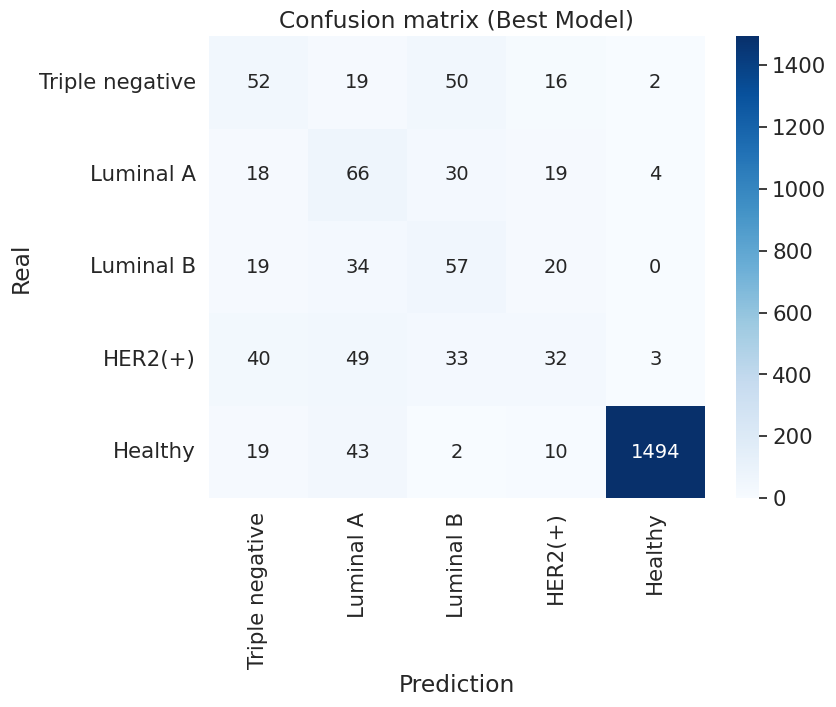


 REPORT COMPLETED (Best Model)
                 precision    recall  f1-score   support

Triple negative       0.35      0.37      0.36       139
      Luminal A       0.31      0.48      0.38       137
      Luminal B       0.33      0.44      0.38       130
        HER2(+)       0.33      0.20      0.25       157
        Healthy       0.99      0.95      0.97      1568

       accuracy                           0.80      2131
      macro avg       0.46      0.49      0.47      2131
   weighted avg       0.82      0.80      0.81      2131



In [ ]:
SAVE_PATH = '/content/drive/MyDrive/2nd Challenge/dual_stream_5classes_CIA.pth'
# Initialize the model before loading state_dict
model = DualStreamResNet(num_classes=5).to(DEVICE)

print(f"Loading best weights from: {SAVE_PATH}")
model.load_state_dict(torch.load(SAVE_PATH))

# Place model in eval mode
model.eval()

all_preds = []
all_labels = []
class_names = ['Triple negative', 'Luminal A', 'Luminal B', 'HER2(+)', 'Healthy']

print("Computing confusion matrix of the best model...")

with torch.no_grad():
    for images, masks, labels, _ in val_aug_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        labels = labels.to(DEVICE)

        # Dual Stream Forward
        outputs = model(images, masks)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# PLOT
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Real')
plt.xlabel('Prediction')
plt.title('Confusion matrix (Best Model)')
plt.show()

print("\n REPORT COMPLETED (Best Model)")
print(classification_report(all_labels, all_preds, target_names=class_names))

###**Test Patching Logic**

To ensure consistency with the training phase, test images were processed using a non-overlapping sliding window to extract 224x224 patches. We applied the same tissue-filtering logic used in training to discard uninformative background tiles.

In [ ]:
# CONFIGURATION
TEST_ORIGINAL_IMG_DIR = 'dataset/test_images'
TEST_ORIGINAL_MASK_DIR = 'dataset/test_masks'
SAVE_TEST_PATCH_IMG = 'dataset/test_patches/images'
SAVE_TEST_PATCH_MASK = 'dataset/test_patches/masks'

PATCH_SIZE = 224
STRIDE = 224  # No overlapping for test
TISSUE_THRESHOLD = 0.10 # Same threshold as training

# Cleaning
def reset_folder(path):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path)

print("Reset test folders...")
reset_folder(SAVE_TEST_PATCH_IMG)
reset_folder(SAVE_TEST_PATCH_MASK)

# Tissue filtering (aligned with training one)
def is_tissue(patch_img, threshold=0.10):
    # Converting to HSV
    hsv = cv2.cvtColor(patch_img, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]
    gray = cv2.cvtColor(patch_img, cv2.COLOR_BGR2GRAY)

    # same parameters as training: (Saturation > 15) & (gray < 235)
    tissue_mask = (saturation > 15) & (gray < 235)

    tissue_pixels = np.count_nonzero(tissue_mask)
    total_pixels = patch_img.shape[0] * patch_img.shape[1]

    return (tissue_pixels / total_pixels) > threshold

# PATCHING CICLE
test_patch_data = []
test_files = [f for f in os.listdir(TEST_ORIGINAL_IMG_DIR) if f.endswith(('.png', '.jpg', '.tif'))]

print(f"Elaborationg {len(test_files)} test images...")

for filename in tqdm(test_files):
    img_path = os.path.join(TEST_ORIGINAL_IMG_DIR, filename)
    mask_path = os.path.join(TEST_ORIGINAL_MASK_DIR, filename.replace('img', 'mask'))


    # Manage different extensions
    if not os.path.exists(mask_path):
        mask_path = None

    # "Fake" label for the DataFrame (for debugging, not for inference)
    label = 'Unknown'
    if 'Triple' in filename: label = 'Triple negative'
    elif 'Luminal' in filename and 'A' in filename: label = 'Luminal A'
    elif 'Luminal' in filename and 'B' in filename: label = 'Luminal B'
    elif 'HER2' in filename: label = 'HER2(+)'

    # Loading
    img = cv2.imread(img_path)
    if img is None: continue

    h, w, _ = img.shape

    # Mask management: if missing, we create a black one as a fallback
    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: mask = np.zeros((h, w), dtype=np.uint8)
    else:
        mask = np.zeros((h, w), dtype=np.uint8)

    # Sliding Window
    saved_count = 0
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):

            patch_img = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            # FILTER: save if there is tissue above that threshold
            if is_tissue(patch_img, threshold=TISSUE_THRESHOLD):

                patch_mask = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

                clean_name = os.path.splitext(filename)[0]
                fname = f"{clean_name}_y{y}_x{x}.png"

                save_img_path = os.path.join(SAVE_TEST_PATCH_IMG, fname)
                save_mask_path = os.path.join(SAVE_TEST_PATCH_MASK, fname.replace('img', 'mask'))


                cv2.imwrite(save_img_path, patch_img)
                cv2.imwrite(save_mask_path, patch_mask)

                test_patch_data.append({
                    'path_img': save_img_path,
                    'path_mask': save_mask_path,
                    'label': label,
                    'original_img': clean_name
                })
                saved_count += 1

    # Security fallback:
    # if there is no patch passing the filter for an image, let's save the center!
    # This guarantees to have at least one prediction for each image.
    if saved_count == 0:
        cy, cx = h // 2, w // 2
        y = max(0, min(cy - PATCH_SIZE // 2, h - PATCH_SIZE))
        x = max(0, min(cx - PATCH_SIZE // 2, w - PATCH_SIZE))

        patch_img = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        patch_mask = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        fname = f"{os.path.splitext(filename)[0]}_FORCED.png"
        save_img_path = os.path.join(SAVE_TEST_PATCH_IMG, fname)
        save_mask_path = os.path.join(SAVE_TEST_PATCH_MASK, fname.replace('img', 'mask'))


        cv2.imwrite(save_img_path, patch_img)
        cv2.imwrite(save_mask_path, patch_mask)

        test_patch_data.append({
            'path_img': save_img_path,
            'path_mask': save_mask_path,
            'label': label,
            'original_img': os.path.splitext(filename)[0]
        })

# Creating test DataFrame
test_df = pd.DataFrame(test_patch_data)
print("\nPATCHING TEST COMPLETATO")
print(f"Totale Patch: {len(test_df)}")
print(f"Immagini originali coperte: {test_df['original_img'].nunique()} (Atteso: {len(test_files)})")

# Saving CSV for inference
test_df.to_csv('test_patches_5classes.csv', index=False)

Reset test folders...
Elaborationg 477 test images...


  0%|          | 0/477 [00:00<?, ?it/s]


PATCHING TEST COMPLETATO
Totale Patch: 4855
Immagini originali coperte: 477 (Atteso: 477)


##**Inference**


Since our model operates on local patches (224x224), while the final classification target is the Whole Slide Image, we implemented a multi-stage inference pipeline designed to maximize robustness and mitigate class confusion.

1. **Patch Prediction with Test Time Augmentation (TTA):** To reduce the variance of individual predictions and exploit the rotational invariance of histological tissues, we applied Test Time Augmentation.

2. **Suspicion-Based Filtering (Top-K Strategy)**: A major challenge in WSI classification is that large portions of a tumor slide may consist of healthy tissue or background. Averaging predictions across all patches would dilute the pathological signal. To address this, we utilized the predicted probability of the "Healthy" class as a noise filter. For each patient, we ranked all extracted patches based on their "Healthy" probability in ascending order. We selected only the Top-K (K=20) patches—effectively isolating the "most suspicious" regions where the model detected the strongest tumor features.

3. **Weighted Soft Voting**: the final image-level label is derived from the average probability of the 4 tumor subtypes across the selected Top-K patches. However, based on validation error analysis, we observed a recurrent confusion between Luminal A and Luminal B. To correct this, we applied a heuristic Class Boosting step before the final decision.

The final class is assigned via argmax on these recalibrated probabilities. This strategy effectively combines the model's confidence with domain-specific adjustments to minimize critical misclassifications.

In [ ]:
# CONFIGURATION
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '/content/drive/MyDrive/2nd Challenge/dual_stream_5classes_CIA_HT_1.pth'
SAVE_SUBMISSION_PATH = '/content/drive/MyDrive/2nd Challenge/submission_logic_corrected_ww3_HT_2h.csv'

# DEFINITIONS & TRANSFORMATIONS

# Normalizations for images
test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Normalizations for masks
mask_only_transform = A.Compose([
    A.ToFloat(max_value=255.0), # Dividing per 255.0
    ToTensorV2()
])

# Creation test dataset e data loader (AugmentedDataset and make_loader previously defined)
test_aug_ds = AugmentedDataset(
    dataframe=test_df,
    label_map=class_map,
    image_transform=test_transform,
    mask_transform=mask_only_transform
)

test_loader = make_loader(test_aug_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# INFERENCE LOOP
print("Starting inference...")
patch_results = []
tumor_classes = ['Triple negative', 'Luminal A', 'Luminal B', 'HER2(+)']

#5 classes like in training
model = DualStreamResNet(num_classes=5).to(DEVICE)

print(f"Loading best weights from: {MODEL_PATH}")
model.load_state_dict(torch.load(MODEL_PATH))

model.eval()

for images, masks, labels, original_img_names_batch in tqdm(test_loader, desc="Inference"):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    with torch.no_grad():
        # Forward pass standard
        outputs = model(images, masks)
        probs_batch = F.softmax(outputs, dim=1).cpu().numpy()

        # Test Time Augmentation: rotation 90 degrees
        img_rot_batch = torch.rot90(images, k=1, dims=[2, 3])
        mask_rot_batch = torch.rot90(masks, k=1, dims=[2, 3])
        outputs_rot_batch = model(img_rot_batch, mask_rot_batch)
        probs_rot_batch = F.softmax(outputs_rot_batch, dim=1).cpu().numpy()

        # Mean of the probability between the image and their rotations (TTA)
        mean_probs_batch = (probs_batch + probs_rot_batch) / 2

    # Saving results for each patch
    for i in range(len(original_img_names_batch)):
        original_img_name = original_img_names_batch[i]
        mean_probs = mean_probs_batch[i]

        patch_data = {
            'original_img': original_img_name,
            'prob_Healthy': mean_probs[4], # Index 4 is Healthy class
            'pred_class_idx': np.argmax(mean_probs),
            'entropy': -np.sum(mean_probs * np.log(mean_probs + 1e-9))
        }

        for j, name in enumerate(tumor_classes):
            patch_data[f'prob_{name}'] = mean_probs[j]

        patch_results.append(patch_data)

df_probs = pd.DataFrame(patch_results)

# AGGREGATION
print("\nAggregation: Weighted Soft Voting (Boost Luminal B)...")

patient_preds = []
unique_patients = df_probs['original_img'].unique()

K_PATCHES = 20

# Class weighting (Boosting)
# Goal is to privilege, in case of doubt, Luminal B (the most common case) and penalize Luminal A (often confused with Luminal B)
CLASS_WEIGHTS = {
    'Luminal A':       0.95,
    'Luminal B':       1.25,
    'HER2(+)':         1,
    'Triple negative': 1
}

count_swapped_to_B = 0

for patient_id in unique_patients:
    patches = df_probs[df_probs['original_img'] == patient_id]

    # Filter Top-K: we keep only the one 'less healthy'
    sorted_patches = patches.sort_values(by='prob_Healthy', ascending=True)
    k = min(K_PATCHES, len(sorted_patches))
    suspicious_patches = sorted_patches.head(k)

    # Compute mean of tumor probabilities
    tumor_cols = [f'prob_{name}' for name in tumor_classes]
    avg_probs = suspicious_patches[tumor_cols].mean()

    # Rename index to match the key of weights in the above dictionary
    avg_probs.index = [c.replace('prob_', '') for c in avg_probs.index]

    # Applying weights
    weighted_probs = avg_probs.copy()
    for cls in tumor_classes:
        weighted_probs[cls] = avg_probs[cls] * CLASS_WEIGHTS.get(cls, 1.0)

    # Debug: let's see if there are changes thanks to the weigts
    orig_pred = avg_probs.idxmax()
    final_pred = weighted_probs.idxmax()

    if final_pred == 'Luminal B' and orig_pred != 'Luminal B':
        count_swapped_to_B += 1

    patient_preds.append(final_pred)

# Creation and save of the submission .csv
clean_ids = [str(p) + '.png' if not str(p).endswith('.png') else str(p) for p in unique_patients]
submission_df = pd.DataFrame({'sample_index': clean_ids, 'label': patient_preds})
submission_df = submission_df.sort_values('sample_index')
submission_df.to_csv(SAVE_SUBMISSION_PATH, index=False)

print(f"\n Submission saved at: {SAVE_SUBMISSION_PATH}")
print(f"Patients converted to Luminal B with boost: {count_swapped_to_B}")
print("\nFinal distribution (after boost):")
print(submission_df['label'].value_counts())

Starting inference...
Loading best weights from: /content/drive/MyDrive/2nd Challenge/dual_stream_5classes_CIA_HT_1.pth


Inference:   0%|          | 0/152 [00:00<?, ?it/s]


Aggregation: Weighted Soft Voting (Boost Luminal B)...

 Submission saved at: /content/drive/MyDrive/2nd Challenge/submission_logic_corrected_ww3_HT_2h.csv
Patients converted to Luminal B with boost: 151

Final distribution (after boost):
label
Luminal B          192
Luminal A          130
HER2(+)             99
Triple negative     56
Name: count, dtype: int64
